# Exploratory Data Analysis (EDA)

This notebook explores the cleaned dataset produced by `Exploration_analysis_v2.ipynb`.

**Sections:**
1. Setup & Data Loading
2. Revenue & Employees Distribution
3. Geographic Breakdown (Region / City)
4. NACE Sector Analysis
5. Monthly Time Series (M-0 to M-35)
6. Correlations Between Variables

## 1. Setup & Data Loading

In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

RANDOM_STATE = 42
TICK_STEP    = 3    # show one x-axis label every 3 months on time-series plots

In [4]:
BASE_DIR   = os.getcwd()
input_path = os.path.join(BASE_DIR, 'source', 'dataset_eda.parquet')

df = pd.read_parquet(input_path)
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nColumn types:\n{df.dtypes}')
df.head(3)

Dataset loaded: 16,791 rows x 43 columns

Column types:
NACE         object
NACE_Desc    object
Revenue       int64
Employees     int64
Province     object
City         object
Region       object
M-35          int64
M-34          int64
M-33          int64
M-32          int64
M-31          int64
M-30          int64
M-29          int64
M-28          int64
M-27          int64
M-26          int64
M-25          int64
M-24          int64
M-23          int64
M-22          int64
M-21          int64
M-20          int64
M-19          int64
M-18          int64
M-17          int64
M-16          int64
M-15          int64
M-14          int64
M-13          int64
M-12          int64
M-11          int64
M-10          int64
M-9           int64
M-8           int64
M-7           int64
M-6           int64
M-5           int64
M-4           int64
M-3           int64
M-2           int64
M-1           int64
M-0           int64
dtype: object


,NACE,NACE_Desc,Revenue,Employees,Province,City,Region,M-35,M-34,M-33,...,M-9,M-8,M-7,M-6,M-5,M-4,M-3,M-2,M-1,M-0
0,47.71,Retail sale of clothing in specialised stores,93840,2,PA,Palermo,Sicilia,80,718,3888,...,65919,58362,69779,62338,71332,54796,91169,104473,127672,139105
1,49.41,Freight transport by road,1242280,4,MB,Monza,Lombardia,44520,43793,54545,...,78015,73822,83936,68864,107911,37607,100365,105866,84089,95330
2,47.91,Retail sale via mail order houses or via Internet,44451177,159,MI,Milano,Lombardia,65703,87812,65768,...,35367,41628,60515,57786,85252,76067,86415,75573,101941,237050


In [5]:
# Monthly columns ordered from oldest (M-35) to most recent (M-0)
M_COLS   = [f'M-{i}' for i in range(35, -1, -1)]
M_LABELS = M_COLS   # reused as axis tick labels

print('Monthly columns:', M_COLS[:4], '...', M_COLS[-3:])

Monthly columns: ['M-35', 'M-34', 'M-33', 'M-32'] ... ['M-2', 'M-1', 'M-0']


---
## 2. Revenue & Employees Distribution

Revenue and Employees are typically right-skewed: a small number of large clients
dominates the totals. We inspect both raw and log-transformed distributions and
define size buckets for later segmentation.

In [6]:
print('=== Revenue (EUR) ===')
print(df['Revenue'].describe().apply(lambda x: f'{x:,.0f}'))
print()
print('=== Employees ===')
print(df['Employees'].describe().apply(lambda x: f'{x:,.0f}'))

=== Revenue (EUR) ===
count        16,791
mean      4,330,619
std       8,467,519
min               0
25%           9,122
50%         763,846
75%       3,990,404
max      57,921,550
Name: Revenue, dtype: str

=== Employees ===
count    16,791
mean         24
std         175
min           0
25%           1
50%           6
75%          18
max      19,555
Name: Employees, dtype: str


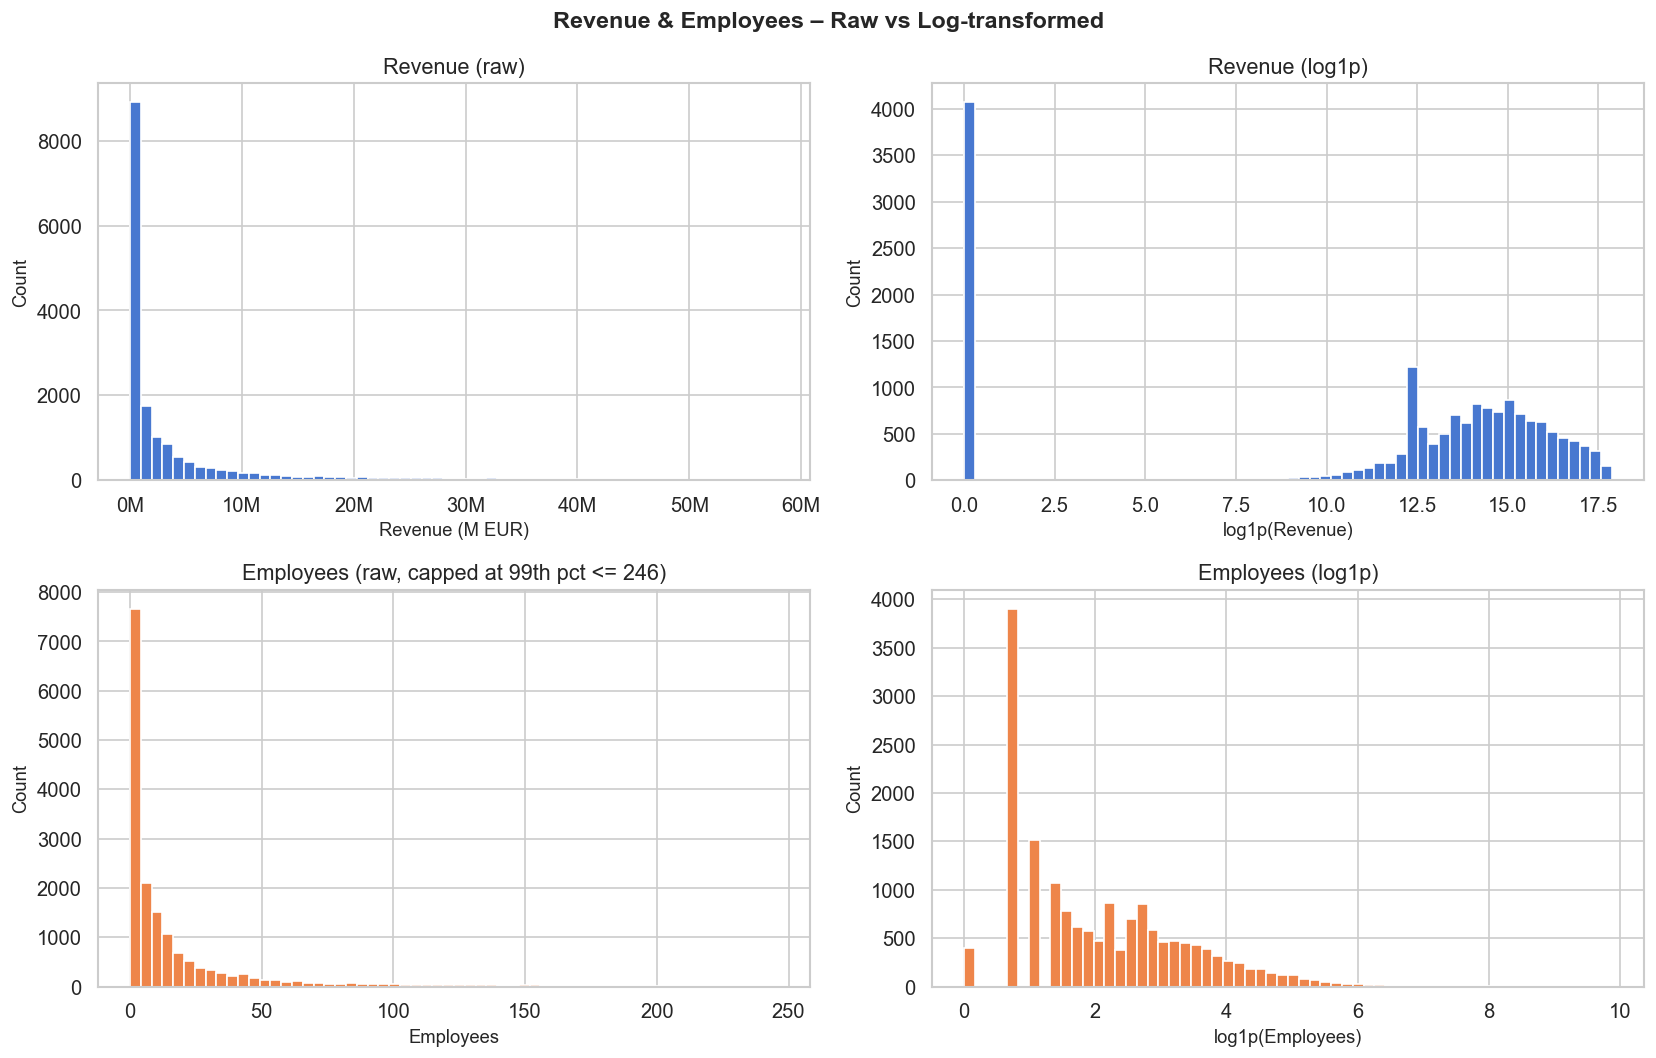

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Revenue & Employees – Raw vs Log-transformed', fontsize=14, fontweight='bold')

pal = sns.color_palette('muted')

# Revenue – raw
axes[0, 0].hist(df['Revenue'] / 1e6, bins=60, color=pal[0], edgecolor='white')
axes[0, 0].set(title='Revenue (raw)', xlabel='Revenue (M EUR)', ylabel='Count')
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

# Revenue – log1p
axes[0, 1].hist(np.log1p(df['Revenue']), bins=60, color=pal[0], edgecolor='white')
axes[0, 1].set(title='Revenue (log1p)', xlabel='log1p(Revenue)', ylabel='Count')

# Employees – raw (capped at 99th percentile for readability)
emp_cap = df['Employees'].quantile(0.99)
axes[1, 0].hist(df.loc[df['Employees'] <= emp_cap, 'Employees'],
                bins=60, color=pal[1], edgecolor='white')
axes[1, 0].set(title=f'Employees (raw, capped at 99th pct <= {emp_cap:.0f})',
               xlabel='Employees', ylabel='Count')

# Employees – log1p
axes[1, 1].hist(np.log1p(df['Employees']), bins=60, color=pal[1], edgecolor='white')
axes[1, 1].set(title='Employees (log1p)', xlabel='log1p(Employees)', ylabel='Count')

plt.tight_layout()
plt.show()

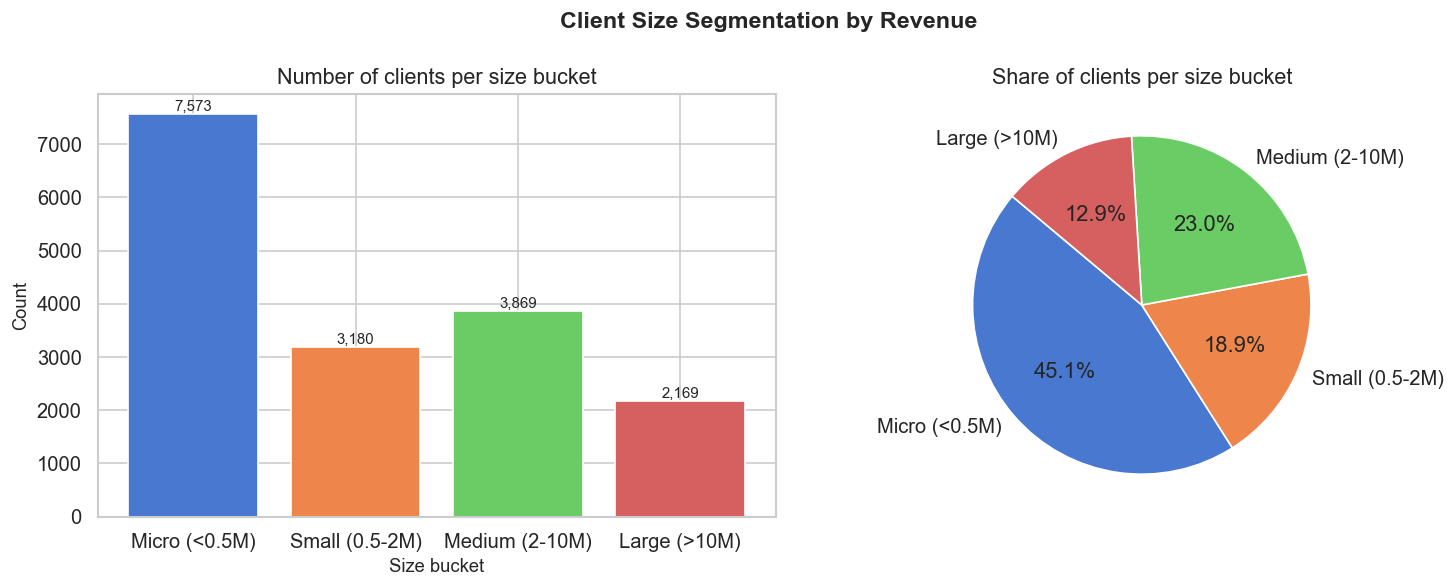

                count   pct
Size_Bucket                
Micro (<0.5M)    7573  45.1
Small (0.5-2M)   3180  18.9
Medium (2-10M)   3869  23.0
Large (>10M)     2169  12.9


In [8]:
# Client size segmentation by Revenue.
# Thresholds (EUR) – adjust to match business definitions if needed.
rev_bins   = [0, 500_000, 2_000_000, 10_000_000, float('inf')]
rev_labels = ['Micro (<0.5M)', 'Small (0.5-2M)', 'Medium (2-10M)', 'Large (>10M)']

df['Size_Bucket'] = pd.cut(df['Revenue'], bins=rev_bins, labels=rev_labels, right=False)
bucket_counts = df['Size_Bucket'].value_counts().reindex(rev_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Client Size Segmentation by Revenue', fontsize=14, fontweight='bold')

# Bar chart – count
axes[0].bar(bucket_counts.index, bucket_counts.values,
            color=sns.color_palette('muted', 4), edgecolor='white')
axes[0].set(title='Number of clients per size bucket',
            xlabel='Size bucket', ylabel='Count')
for i, v in enumerate(bucket_counts.values):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Pie chart – share
axes[1].pie(bucket_counts.values, labels=bucket_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('muted', 4),
            startangle=140, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Share of clients per size bucket')

plt.tight_layout()
plt.show()

print(bucket_counts.to_frame('count').assign(
    pct=lambda d: (d['count'] / d['count'].sum() * 100).round(1)
))

---
## 3. Geographic Breakdown (Region / City)

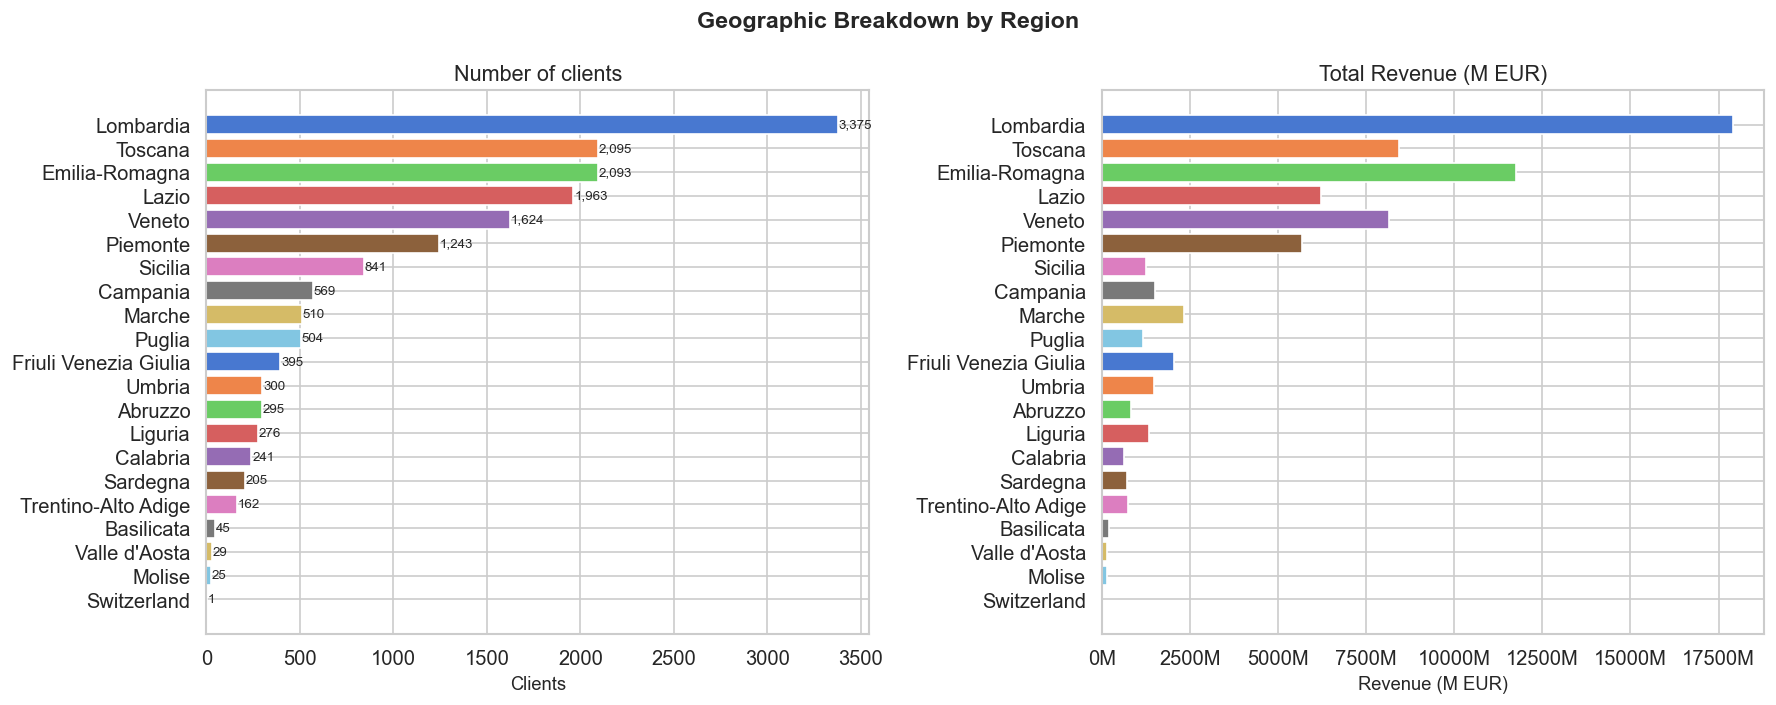

In [9]:
# Aggregate clients and total Revenue by Region
geo_region = (
    df.groupby('Region', observed=True)
    .agg(clients=('Revenue', 'count'), total_revenue=('Revenue', 'sum'))
    .sort_values('clients', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Geographic Breakdown by Region', fontsize=14, fontweight='bold')

# Number of clients per region
axes[0].barh(geo_region.index, geo_region['clients'],
             color=sns.color_palette('muted', len(geo_region)), edgecolor='white')
axes[0].invert_yaxis()
axes[0].set(title='Number of clients', xlabel='Clients', ylabel='')
for i, v in enumerate(geo_region['clients']):
    axes[0].text(v + 5, i, f'{v:,}', va='center', fontsize=8)

# Total Revenue per region
axes[1].barh(geo_region.index, geo_region['total_revenue'] / 1e6,
             color=sns.color_palette('muted', len(geo_region)), edgecolor='white')
axes[1].invert_yaxis()
axes[1].set(title='Total Revenue (M EUR)', xlabel='Revenue (M EUR)', ylabel='')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

plt.tight_layout()
plt.show()

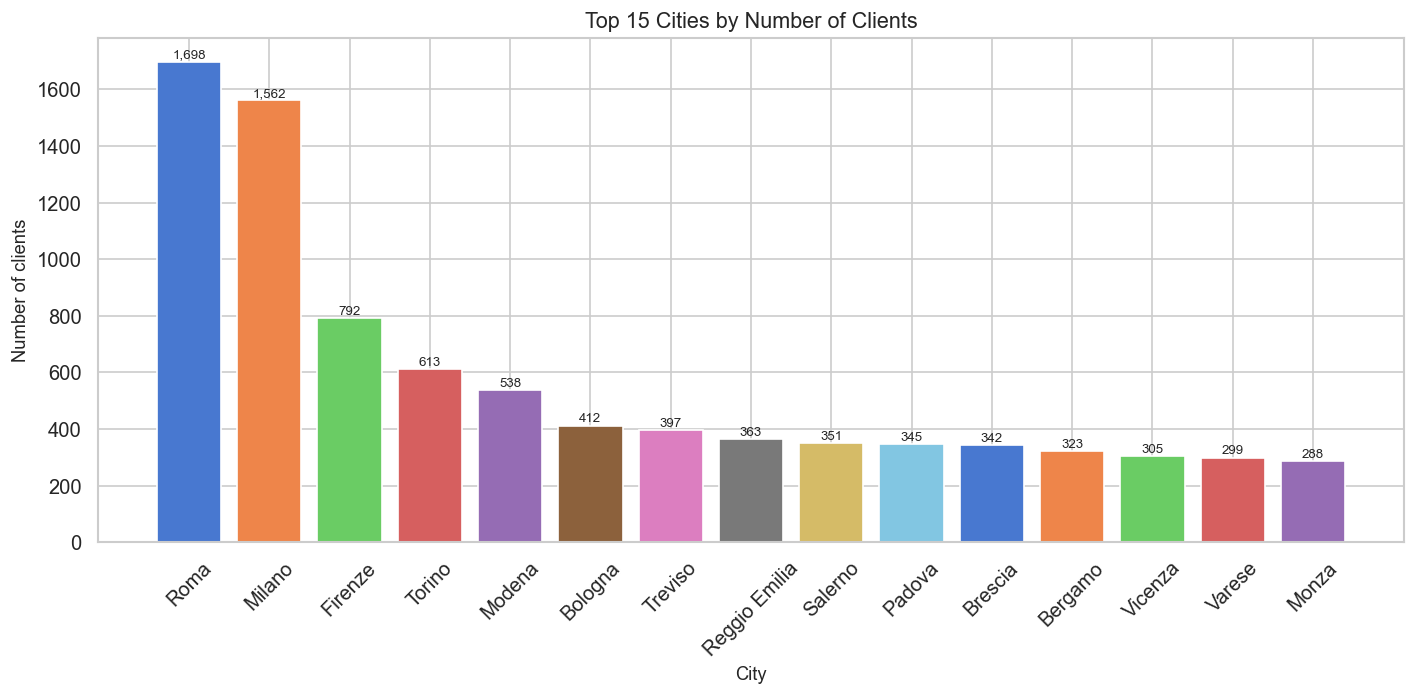

In [10]:
# Top 15 cities by number of clients
top_cities = (
    df.groupby('City', observed=True)
    .agg(clients=('Revenue', 'count'), avg_revenue=('Revenue', 'mean'))
    .sort_values('clients', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top_cities.index, top_cities['clients'],
              color=sns.color_palette('muted', len(top_cities)), edgecolor='white')
ax.set(title='Top 15 Cities by Number of Clients',
       xlabel='City', ylabel='Number of clients')
ax.tick_params(axis='x', rotation=45)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

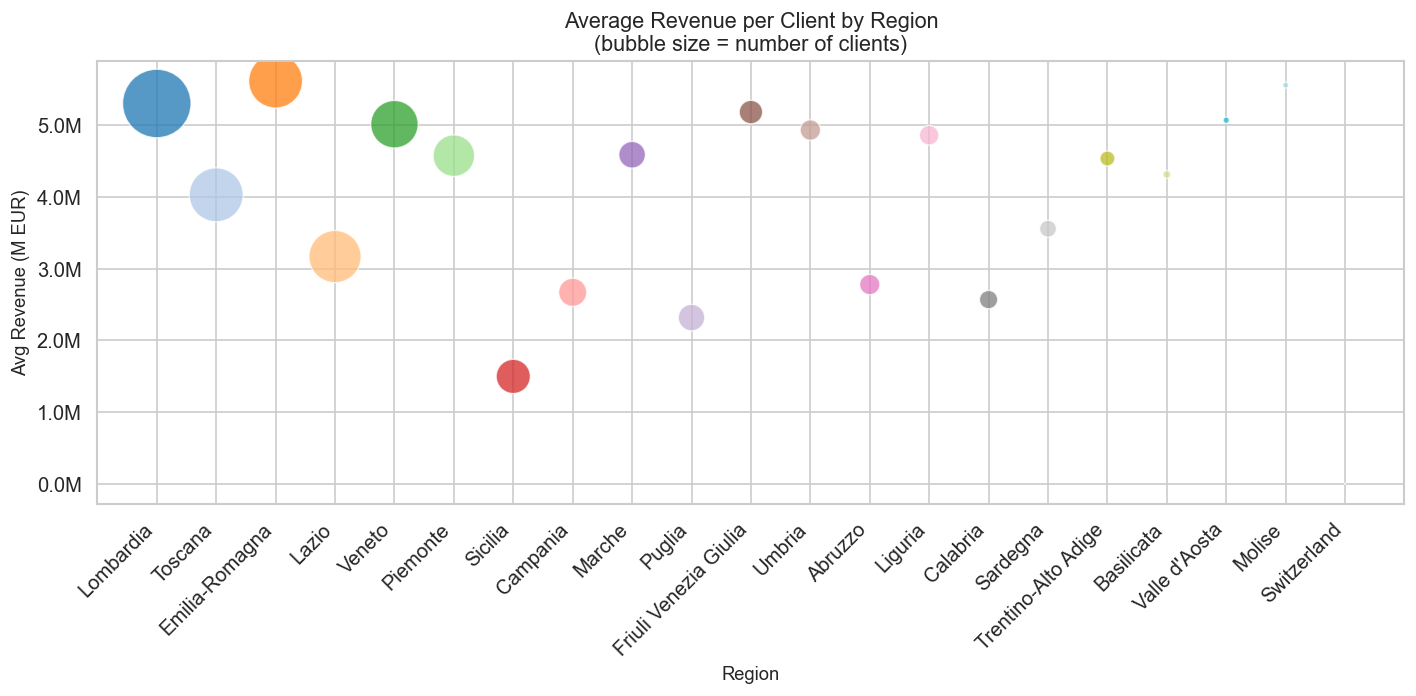

In [11]:
# Bubble chart: average Revenue per client by Region.
# Bubble size is proportional to the number of clients in that region.
geo_region['avg_revenue'] = geo_region['total_revenue'] / geo_region['clients']

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(
    x=range(len(geo_region)),
    y=geo_region['avg_revenue'] / 1e6,
    s=geo_region['clients'] * 0.5,
    c=range(len(geo_region)), cmap='tab20', alpha=0.75,
    edgecolors='white', linewidths=0.8
)
ax.set_xticks(range(len(geo_region)))
ax.set_xticklabels(geo_region.index, rotation=45, ha='right')
ax.set(title='Average Revenue per Client by Region\n(bubble size = number of clients)',
       xlabel='Region', ylabel='Avg Revenue (M EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
plt.tight_layout()
plt.show()

---
## 4. NACE Sector Analysis

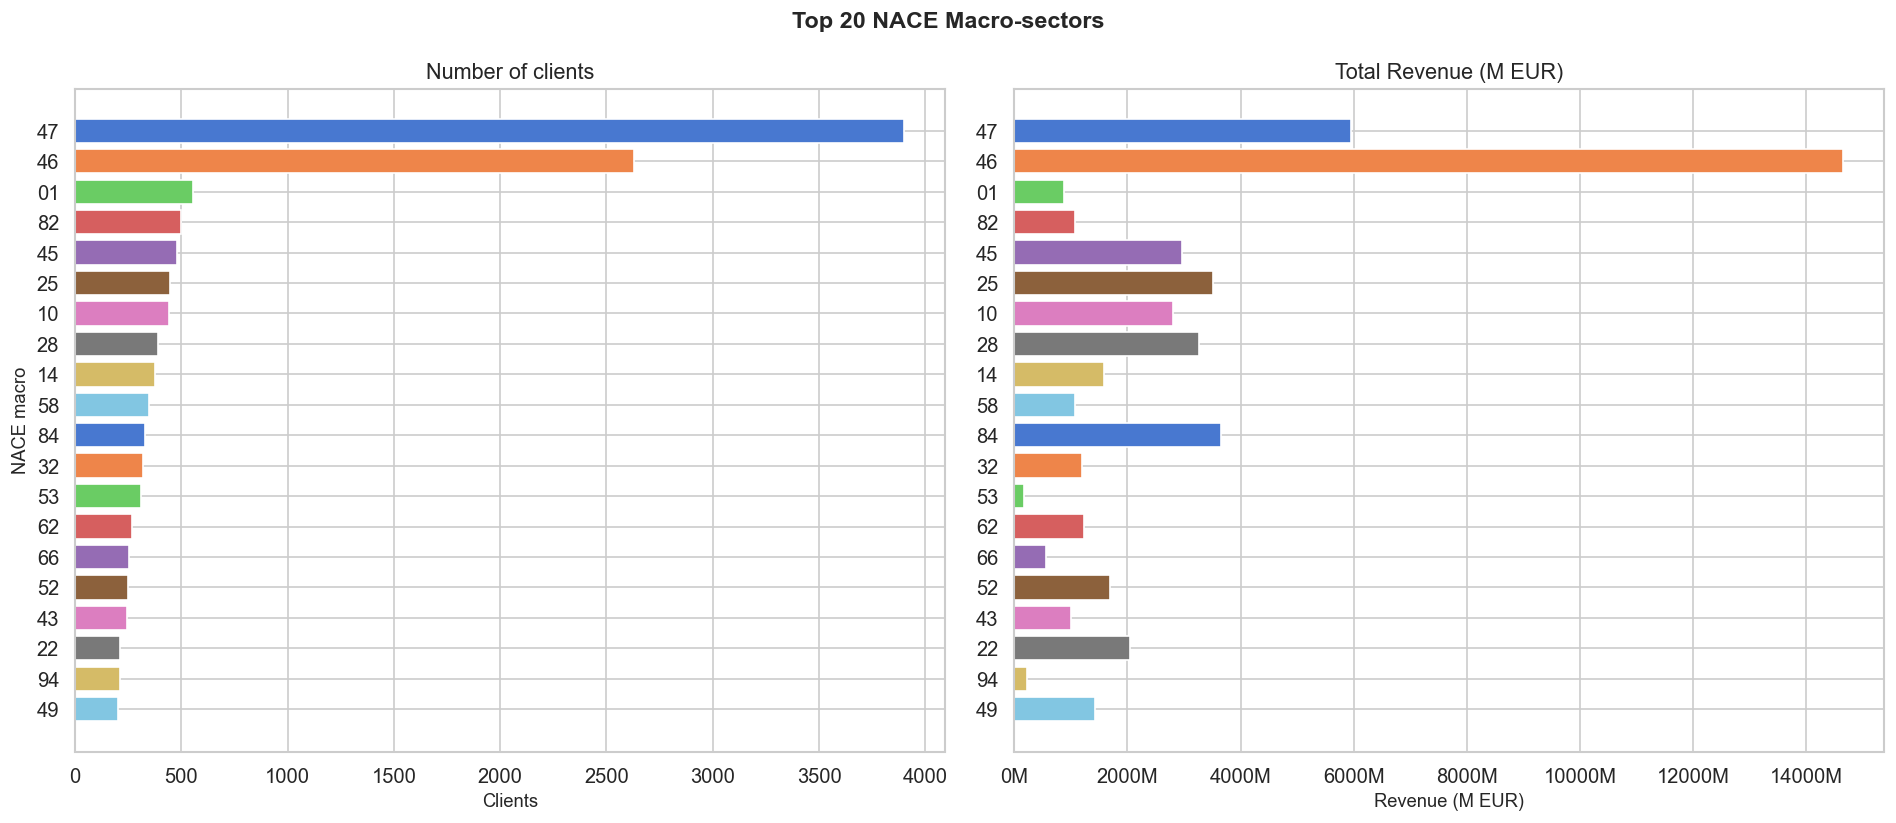

In [12]:
# Derive a macro-sector code from the first 2 digits of the NACE code
df['NACE_macro'] = df['NACE'].astype(str).str[:2]

macro_stats = (
    df.groupby('NACE_macro', observed=True)
    .agg(clients=('Revenue', 'count'), total_revenue=('Revenue', 'sum'))
    .sort_values('clients', ascending=False)
    .head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Top 20 NACE Macro-sectors', fontsize=14, fontweight='bold')

axes[0].barh(macro_stats.index, macro_stats['clients'],
             color=sns.color_palette('muted', len(macro_stats)), edgecolor='white')
axes[0].invert_yaxis()
axes[0].set(title='Number of clients', xlabel='Clients', ylabel='NACE macro')

axes[1].barh(macro_stats.index, macro_stats['total_revenue'] / 1e6,
             color=sns.color_palette('muted', len(macro_stats)), edgecolor='white')
axes[1].invert_yaxis()
axes[1].set(title='Total Revenue (M EUR)', xlabel='Revenue (M EUR)', ylabel='')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

plt.tight_layout()
plt.show()

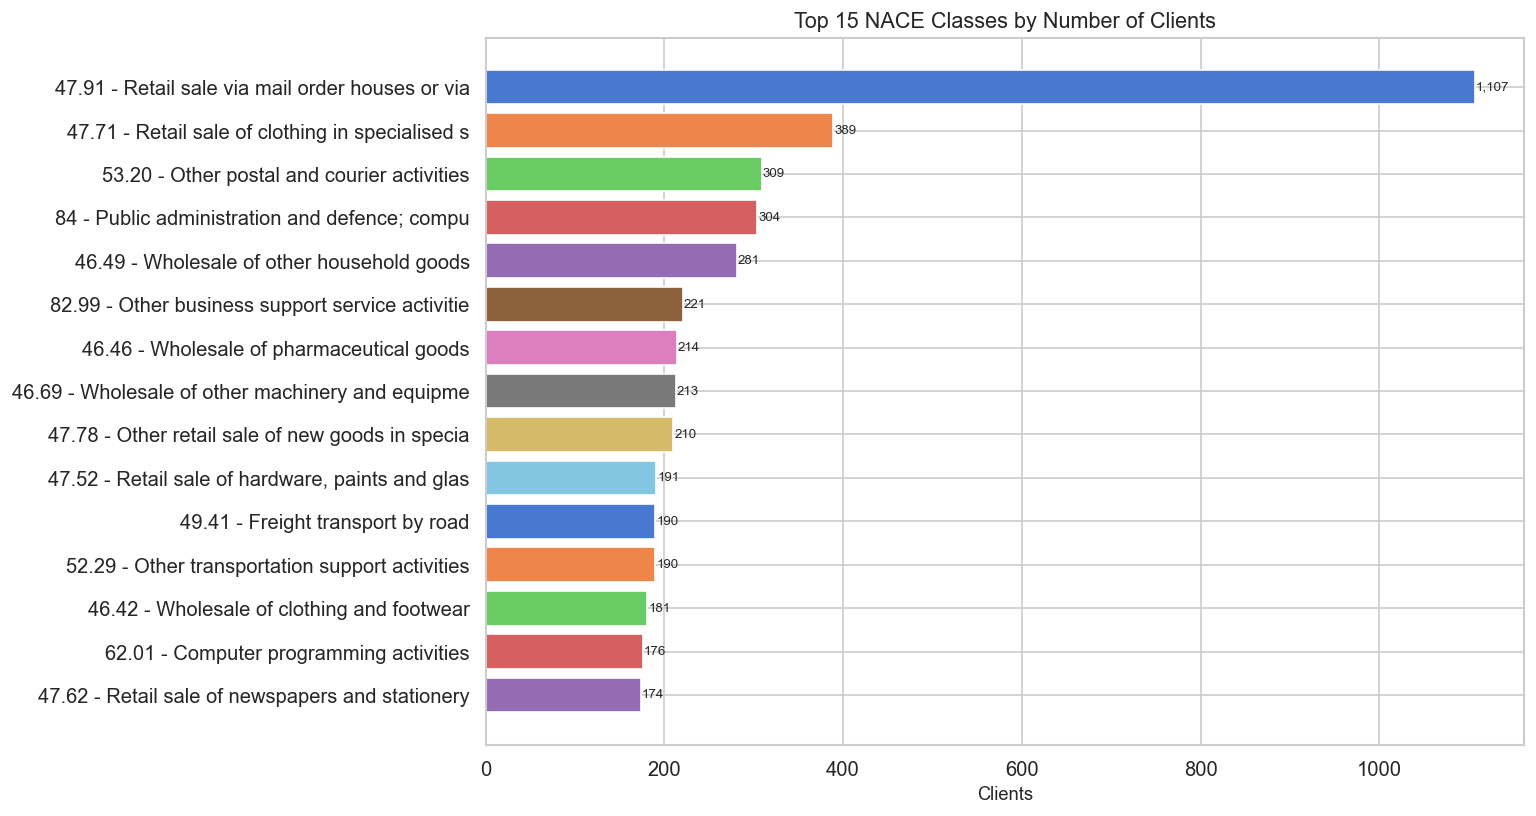

In [13]:
# Top 15 NACE classes (4-digit level) by number of clients
nace_top = (
    df.groupby(['NACE', 'NACE_Desc'], observed=True)
    .agg(clients=('Revenue', 'count'), total_revenue=('Revenue', 'sum'),
         avg_revenue=('Revenue', 'mean'))
    .sort_values('clients', ascending=False)
    .head(15)
    .reset_index()
)
# Shorten descriptions for axis labels
nace_top['label'] = nace_top['NACE'] + ' - ' + nace_top['NACE_Desc'].str[:40]

fig, ax = plt.subplots(figsize=(13, 7))
ax.barh(nace_top['label'], nace_top['clients'],
        color=sns.color_palette('muted', len(nace_top)), edgecolor='white')
ax.invert_yaxis()
ax.set(title='Top 15 NACE Classes by Number of Clients',
       xlabel='Clients', ylabel='')
for i, v in enumerate(nace_top['clients']):
    ax.text(v + 1, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

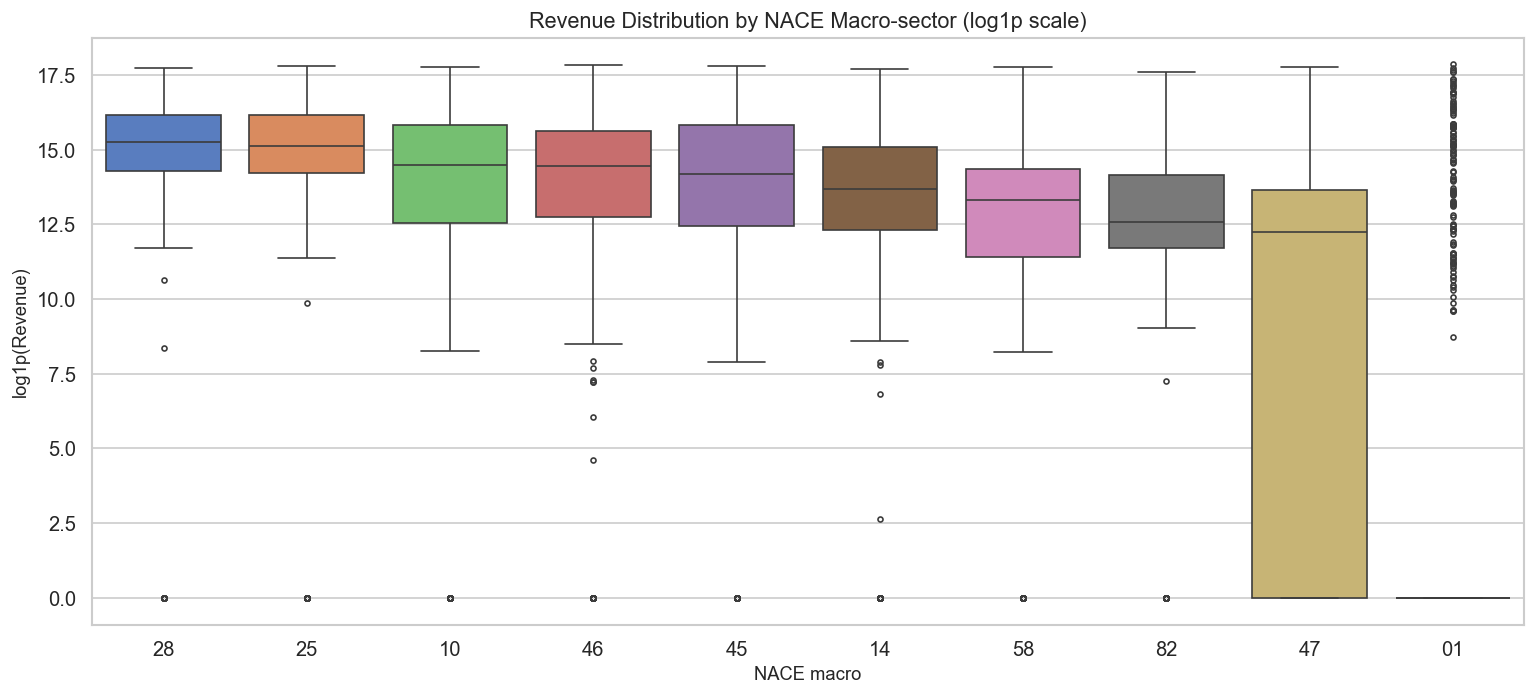

In [14]:
# Revenue distribution across the top 10 NACE macro-sectors (log scale boxplot)
top10_macro = df['NACE_macro'].value_counts().head(10).index.tolist()
df_top10 = df[df['NACE_macro'].isin(top10_macro)].copy()
df_top10['log_revenue'] = np.log1p(df_top10['Revenue'])

order = (
    df_top10.groupby('NACE_macro')['log_revenue']
    .median().sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=df_top10, x='NACE_macro', y='log_revenue',
            order=order, palette='muted', ax=ax,
            flierprops=dict(markersize=3))
ax.set(title='Revenue Distribution by NACE Macro-sector (log1p scale)',
       xlabel='NACE macro', ylabel='log1p(Revenue)')
plt.tight_layout()
plt.show()

---
## 5. Monthly Time Series (M-0 to M-35)

`M-35` is the oldest month; `M-0` is the most recent.
The columns represent monthly transaction volumes per client.

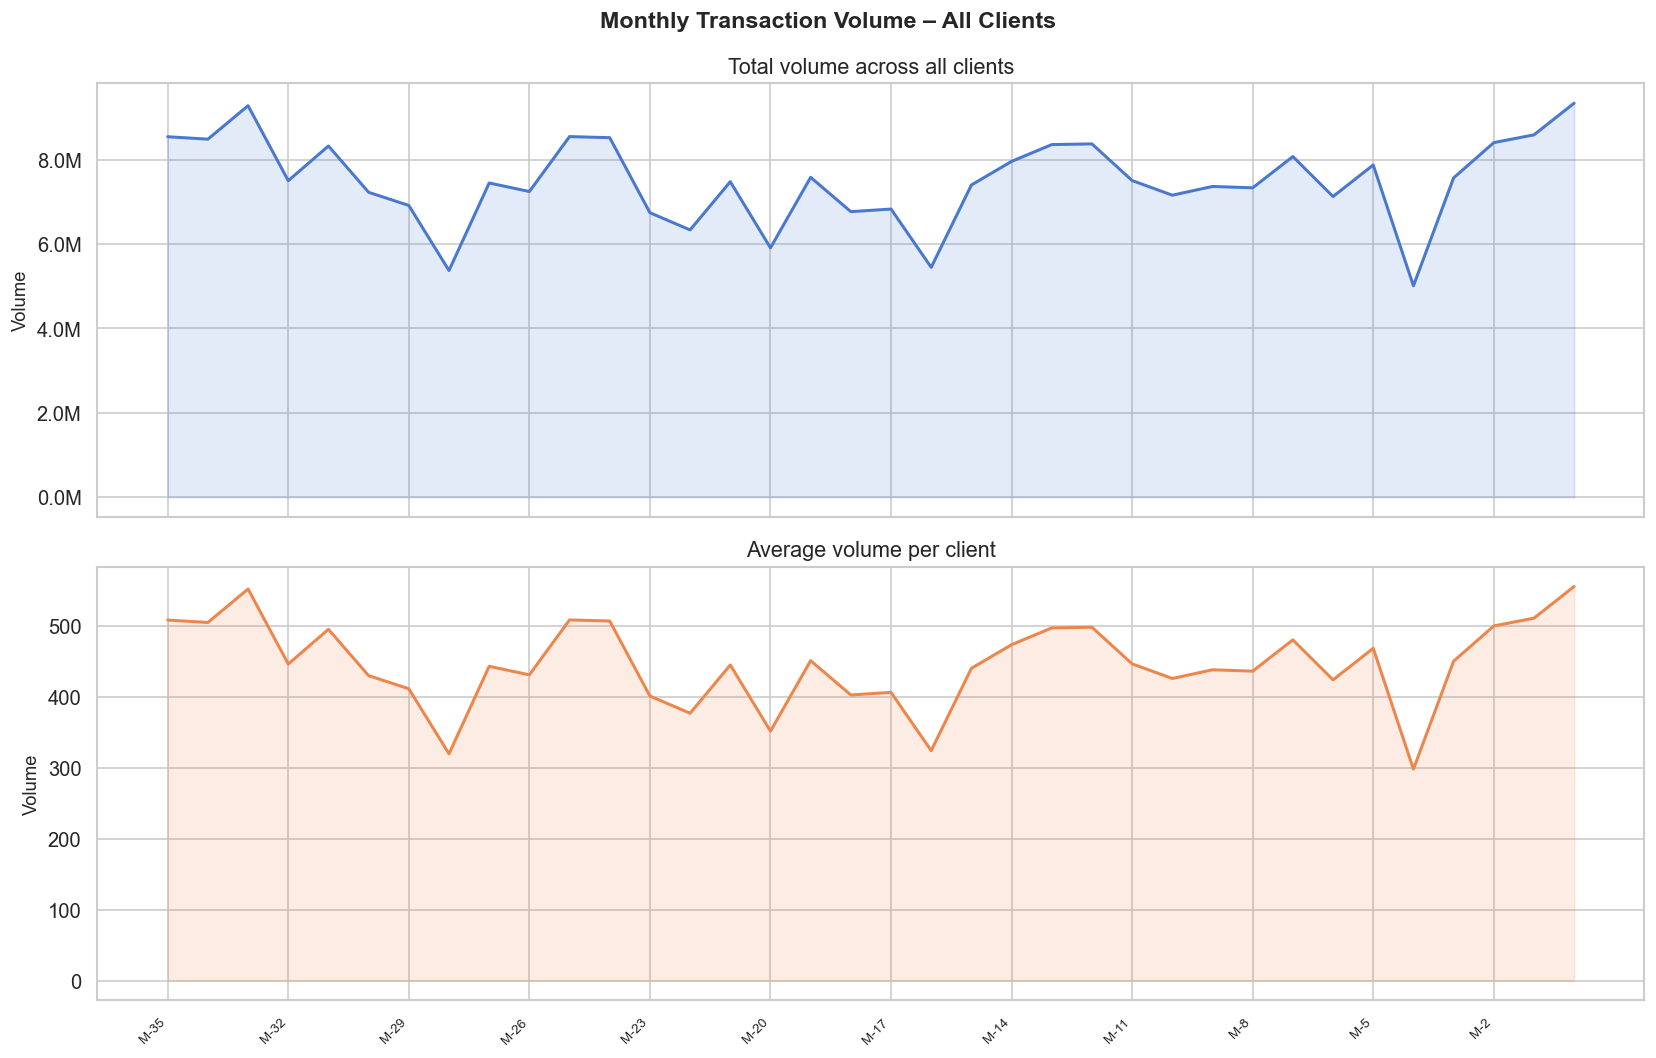

In [15]:
# Total and average monthly volume across all clients
monthly_total = df[M_COLS].sum()
monthly_mean  = df[M_COLS].mean()

x = range(len(M_COLS))

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Monthly Transaction Volume – All Clients', fontsize=14, fontweight='bold')

axes[0].plot(x, monthly_total.values, color=sns.color_palette('muted')[0], linewidth=1.8)
axes[0].fill_between(x, monthly_total.values, alpha=0.15, color=sns.color_palette('muted')[0])
axes[0].set(title='Total volume across all clients', ylabel='Volume')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))

axes[1].plot(x, monthly_mean.values, color=sns.color_palette('muted')[1], linewidth=1.8)
axes[1].fill_between(x, monthly_mean.values, alpha=0.15, color=sns.color_palette('muted')[1])
axes[1].set(title='Average volume per client', ylabel='Volume')
axes[1].set_xticks(list(x)[::TICK_STEP])
axes[1].set_xticklabels(M_LABELS[::TICK_STEP], rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

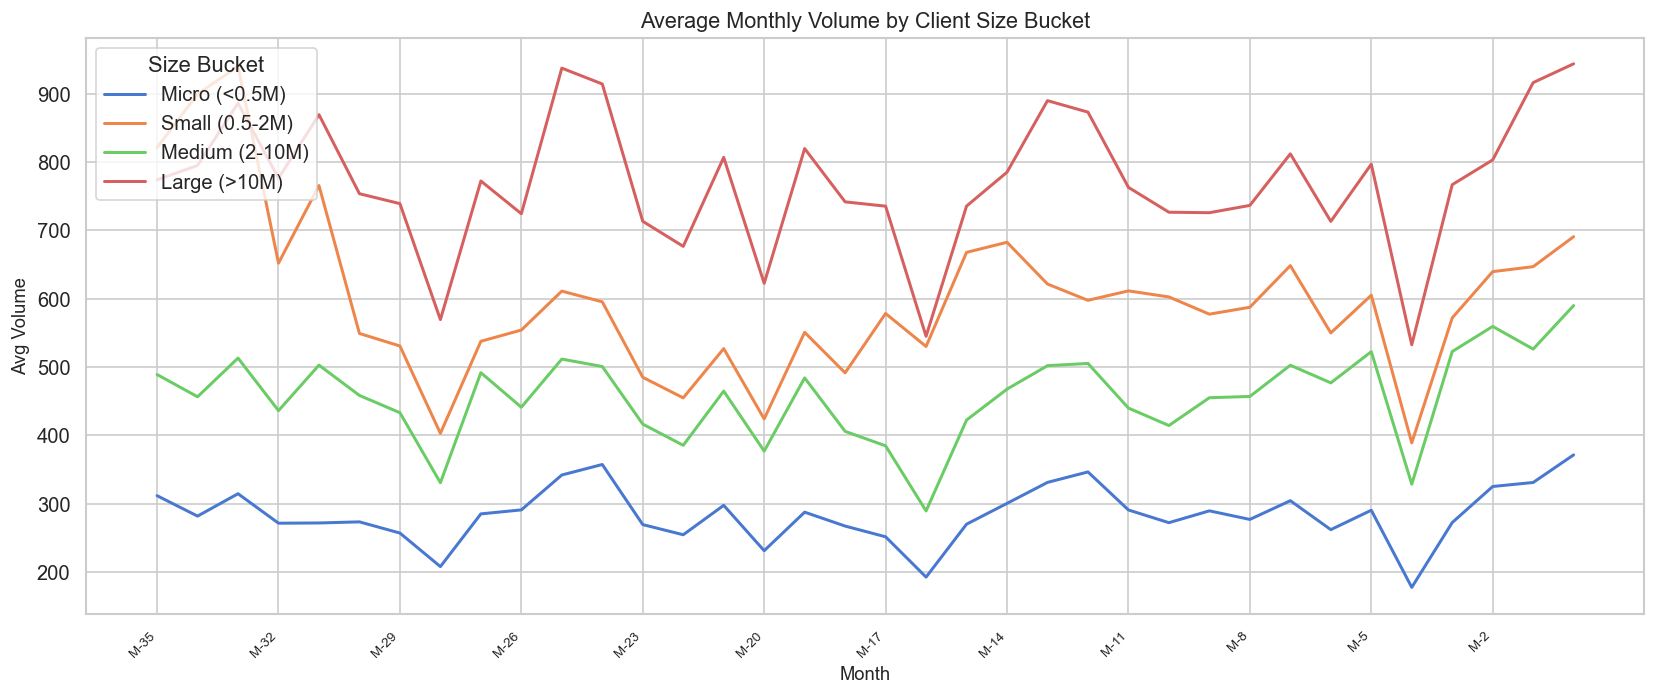

In [16]:
# Average monthly volume broken down by client Size Bucket
ts_size = df.groupby('Size_Bucket', observed=True)[M_COLS].mean()
palette  = sns.color_palette('muted', len(ts_size))

fig, ax = plt.subplots(figsize=(14, 6))
for i, (bucket, row) in enumerate(ts_size.iterrows()):
    ax.plot(range(len(M_COLS)), row.values, label=bucket,
            color=palette[i], linewidth=1.8)

ax.set_xticks(range(0, len(M_COLS), TICK_STEP))
ax.set_xticklabels(M_LABELS[::TICK_STEP], rotation=45, ha='right', fontsize=8)
ax.set(title='Average Monthly Volume by Client Size Bucket',
       xlabel='Month', ylabel='Avg Volume')
ax.legend(title='Size Bucket', loc='upper left')
plt.tight_layout()
plt.show()

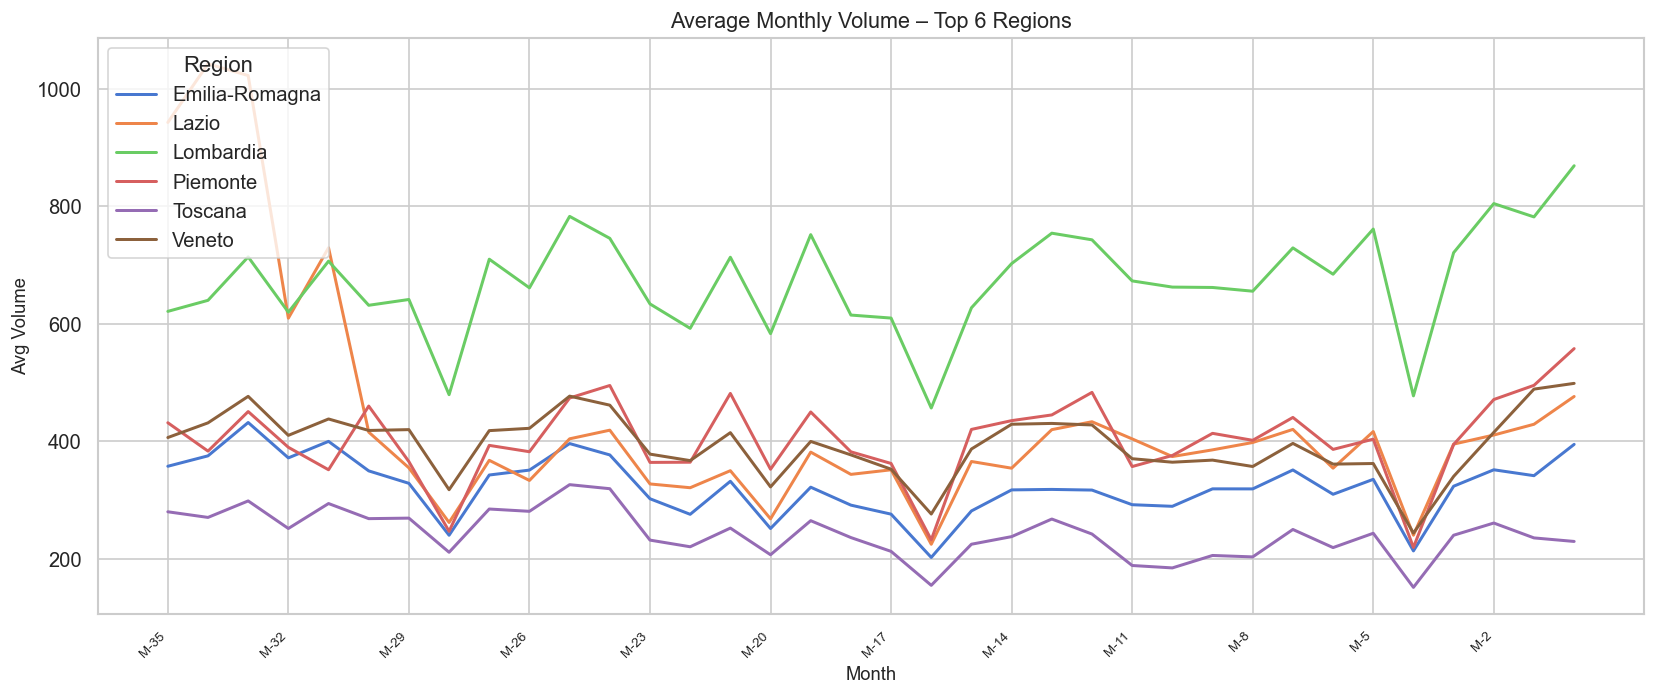

In [17]:
# Average monthly volume for the top 6 Regions by client count
top6_regions = df['Region'].value_counts().head(6).index.tolist()
ts_region    = df[df['Region'].isin(top6_regions)].groupby('Region')[M_COLS].mean()
palette6     = sns.color_palette('muted', 6)

fig, ax = plt.subplots(figsize=(14, 6))
for i, (region, row) in enumerate(ts_region.iterrows()):
    ax.plot(range(len(M_COLS)), row.values, label=region,
            color=palette6[i], linewidth=1.8)

ax.set_xticks(range(0, len(M_COLS), TICK_STEP))
ax.set_xticklabels(M_LABELS[::TICK_STEP], rotation=45, ha='right', fontsize=8)
ax.set(title='Average Monthly Volume – Top 6 Regions',
       xlabel='Month', ylabel='Avg Volume')
ax.legend(title='Region', loc='upper left')
plt.tight_layout()
plt.show()

---
## 6. Correlations Between Variables

In [18]:
# Build derived numeric features used in the correlation analysis
df['total_volume']   = df[M_COLS].sum(axis=1)
df['recent_volume']  = df[[f'M-{i}' for i in range(6)]].sum(axis=1)  # last 6 months
df['volume_trend']   = df['M-0'] - df['M-35']                         # simple delta oldest -> newest
df['log_revenue']    = np.log1p(df['Revenue'])
df['log_employees']  = np.log1p(df['Employees'])
df['log_total_vol']  = np.log1p(df['total_volume'])
df['log_recent_vol'] = np.log1p(df['recent_volume'])

corr_cols = ['log_revenue', 'log_employees',
             'log_total_vol', 'log_recent_vol', 'volume_trend']

corr_matrix = df[corr_cols].corr()
print(corr_matrix.round(3))

                log_revenue  log_employees  log_total_vol  log_recent_vol  \
log_revenue           1.000          0.544          0.041           0.047   
log_employees         0.544          1.000         -0.015           0.037   
log_total_vol         0.041         -0.015          1.000           0.746   
log_recent_vol        0.047          0.037          0.746           1.000   
volume_trend          0.002         -0.013          0.011           0.055   

                volume_trend  
log_revenue            0.002  
log_employees         -0.013  
log_total_vol          0.011  
log_recent_vol         0.055  
volume_trend           1.000  


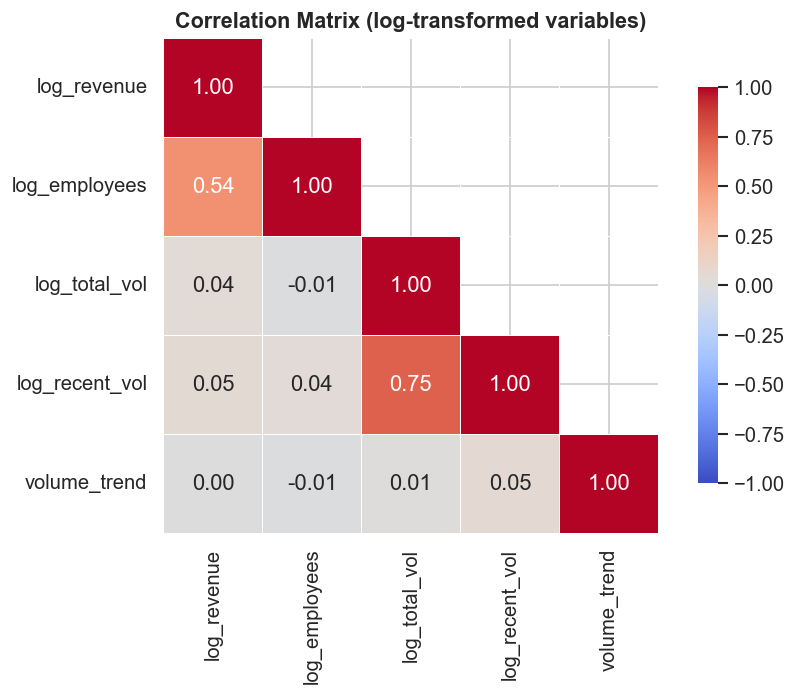

In [19]:
# Lower-triangle heatmap to avoid duplicate cells
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix (log-transformed variables)', fontweight='bold')
plt.tight_layout()
plt.show()

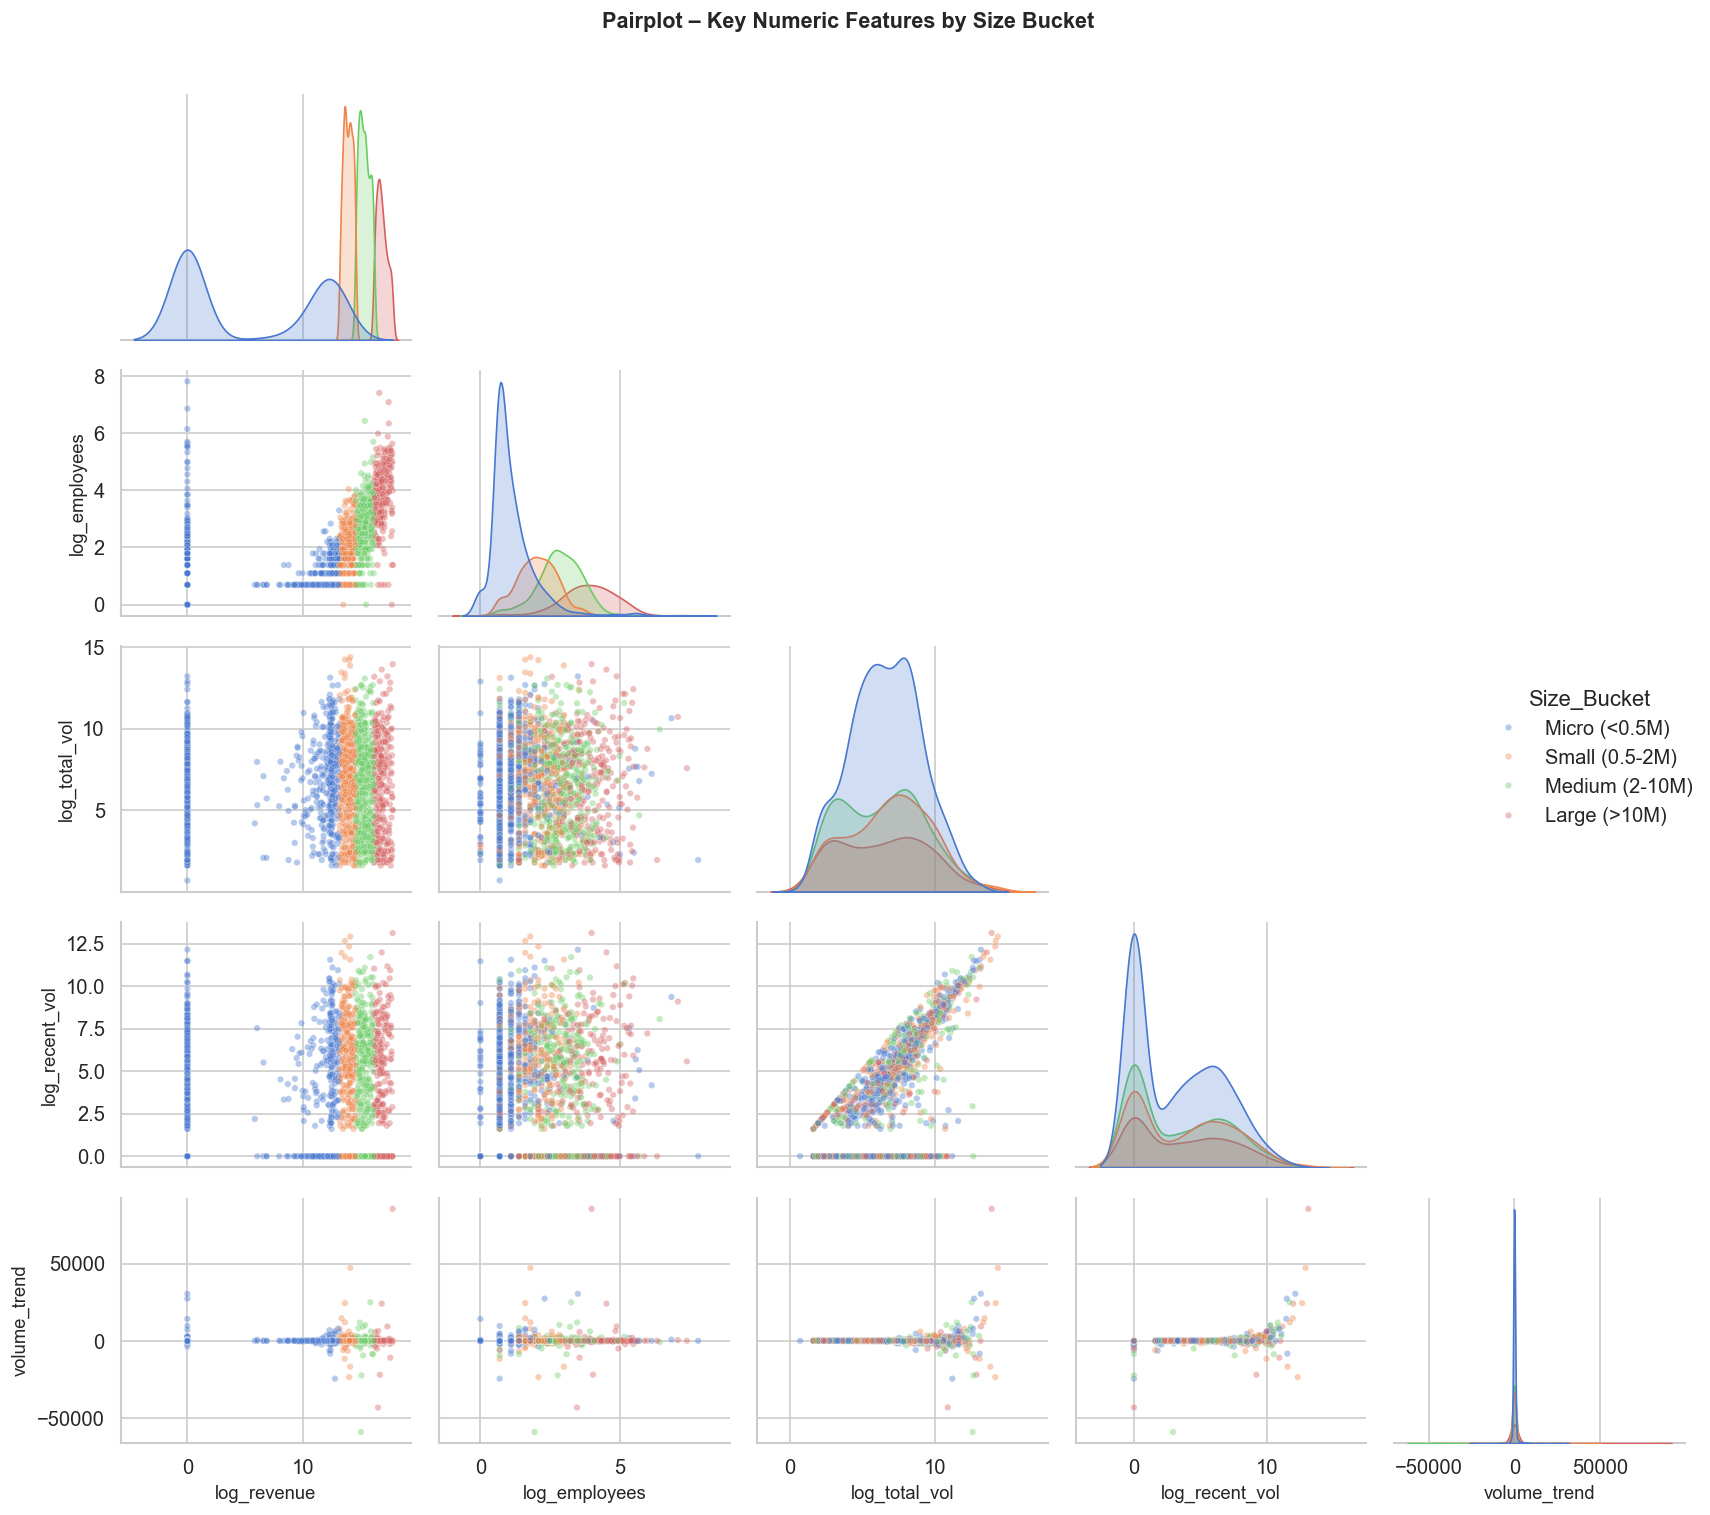

In [20]:
# Pairplot for key numeric features, coloured by Size Bucket.
# Sampled to keep rendering fast on large datasets.
sample_df = df[corr_cols + ['Size_Bucket']].dropna().sample(
    min(2000, len(df)), random_state=RANDOM_STATE
)

g = sns.pairplot(
    sample_df, hue='Size_Bucket', diag_kind='kde',
    plot_kws=dict(alpha=0.4, s=15),
    palette='muted', corner=True
)
g.figure.suptitle('Pairplot – Key Numeric Features by Size Bucket',
                   y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

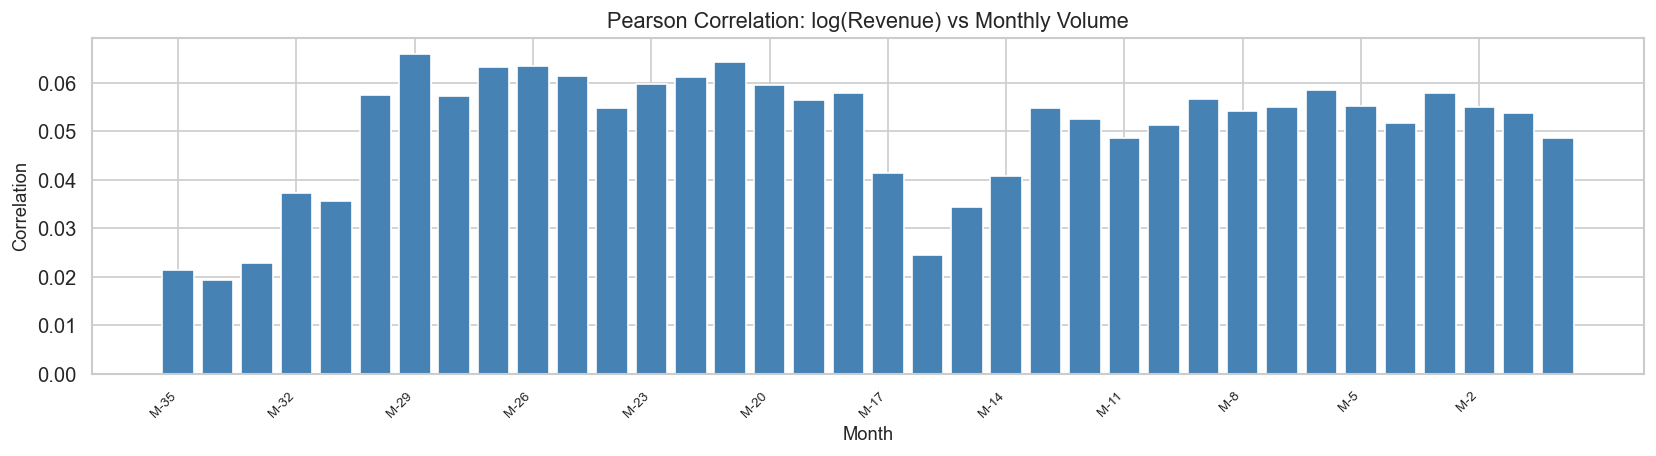

In [21]:
# Pearson correlation between log(Revenue) and each monthly volume column.
# A consistently high correlation suggests that high-revenue clients
# also ship more throughout the entire observation window.
monthly_rev_corr = (
    df[['log_revenue'] + M_COLS]
    .corr()['log_revenue']
    .drop('log_revenue')
)

colors = ['steelblue' if v >= 0 else 'tomato' for v in monthly_rev_corr.values]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(M_COLS)), monthly_rev_corr.values,
       color=colors, edgecolor='white', width=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(0, len(M_COLS), TICK_STEP))
ax.set_xticklabels(M_LABELS[::TICK_STEP], rotation=45, ha='right', fontsize=8)
ax.set(title='Pearson Correlation: log(Revenue) vs Monthly Volume',
       xlabel='Month', ylabel='Correlation')
plt.tight_layout()
plt.show()